# Input Data Analysis - Baltalimani Outpatient Clinic

This notebook produces the **Section 1.3 Input Data Analysis** content for the IE 304 project report.

Structure:

1. Raw data profile
2. Cleaning audit (via `data_prep.load_and_clean`)
3. Arrival analysis (day-of-week, hour-of-day, inter-arrival times)
4. Routing probabilities per department
5. Service time distributions (histograms + ECDFs)
6. Distribution fitting with goodness-of-fit (K-S + Chi-square)
7. Emit `config.yml`
8. QA sanity check (sample from fitted distributions, compare moments)

All cleaning logic lives in [`data_prep.py`](data_prep.py); this notebook is pure orchestration and visualisation so that the report text can cite concrete numbers without re-running the whole pipeline.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from scipy import stats

import data_prep as dp

DATA_PATH = "Baltalimani_Data_2025.xlsx"
DEPT_MAPPING_PATH = "Baltalimani_Data_2025.csv"
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

RNG = np.random.default_rng(20260423)

## 1. Raw data profile

Before cleaning anything we document the shape of the workbook as it landed on disk. Every number below goes into the *Data Description* subsection of the report.

In [2]:
raw = dp.load_raw(DATA_PATH)
print(f"Raw shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.dtypes.to_frame("dtype")

Raw shape: 12,263 rows x 13 columns


,dtype
HASTA_ADI_SOYADI,str
TC_KIMLIK_NO,str
CINSIYET,str
DOKTOR_ADI,str
DOGUM_YILI,int64
GIRIS_TARIHI,datetime64[us]
RANDEVU_BASLAMA_SAATI,datetime64[us]
MUAYENE_KABUL_ZAMANI,datetime64[us]
CAGRILMA_ZAMANI,datetime64[us]
TETKIK_ISTEK_SAATI,datetime64[us]


In [3]:
missing = raw.isna().sum().to_frame("missing")
missing["missing_pct"] = (missing["missing"] / len(raw) * 100).round(2)
missing.sort_values("missing", ascending=False)

,missing,missing_pct
RONTGEN_ODA_NO,5087,41.48
CEKIM_ZAMANI,5064,41.29
TETKIK_ISTEK_SAATI,4935,40.24
CAGRILMA_ZAMANI,3466,28.26
MUAYENE_SONLANDIRMA_ZAMANI,1095,8.93
MUAYENE_KABUL_ZAMANI,586,4.78
DOGUM_YILI,0,0.00
CINSIYET,0,0.00
TC_KIMLIK_NO,0,0.00
HASTA_ADI_SOYADI,0,0.00


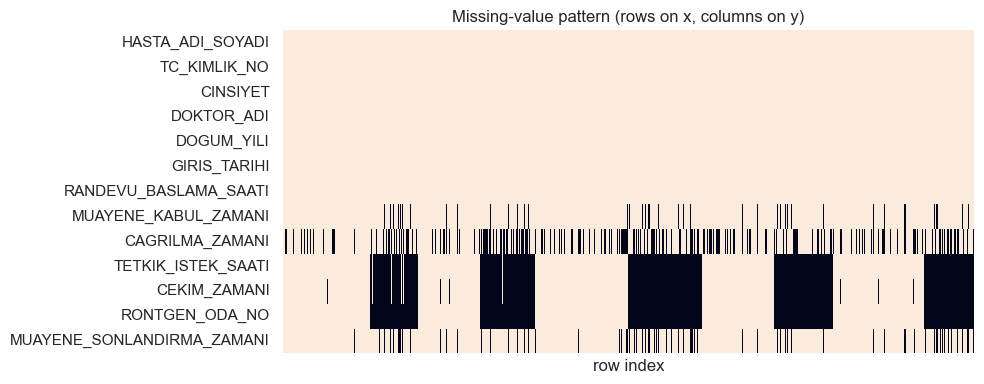

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(raw.isna().T, cbar=False, ax=ax, cmap="rocket_r")
ax.set_title("Missing-value pattern (rows on x, columns on y)")
ax.set_xlabel("row index")
ax.set_xticks([])
fig.tight_layout()
fig.savefig(OUT_DIR / "missing_value_heatmap.png", dpi=150)
plt.show()

## 2. Cleaning audit

The cleaning pipeline runs in 10 deterministic steps. The audit table below reports how many rows each step consumed or masked; copy it verbatim into the report appendix.

In [5]:
doctor_to_department = dp.load_doctor_department_mapping(DEPT_MAPPING_PATH)
all_departments = {d for specs in doctor_to_department.values() for d in specs}
multi_specialty_doctors = {d: specs for d, specs in doctor_to_department.items() if len(specs) > 1}

print(f"Loaded mapping: {len(doctor_to_department)} doctors -> {len(all_departments)} distinct specialties")
print(f"Doctors with >1 specialty: {len(multi_specialty_doctors)}")
if multi_specialty_doctors:
    for doc, specs in sorted(multi_specialty_doctors.items()):
        print(f"  {doc}: {specs}")

df, log = dp.load_and_clean(DATA_PATH, doctor_to_department=doctor_to_department)

unmapped = sorted(set(df["DOKTOR_ADI"].unique()) - set(doctor_to_department))
if unmapped:
    print(f"\nWARNING: {len(unmapped)} doctors in data but not in the mapping CSV: {unmapped}")
else:
    print("\nAll doctors in the data are present in the mapping CSV.")

audit = log.to_frame()
audit.to_csv(OUT_DIR / "cleaning_audit.csv", index=False)
audit

Loaded mapping: 32 doctors -> 9 distinct specialties
Doctors with >1 specialty: 12
  AHMET FIRAT BERKAY: ['ShoulderSports', 'KneeMeniscus']
  AHMET KOCABIYIK: ['AdultHipKnee', 'BoneDeformity']
  BARIŞ ÇAYPINAR: ['AdultHipKnee', 'Spine']
  BARIŞ ÖZKUL: ['AdultHipKnee', 'BoneDeformity']
  DENİZ KARGIN: ['AdultHipKnee', 'Spine']
  GÖKHAN PEHLİVANOĞLU: ['ShoulderSports', 'KneeMeniscus']
  KADİR İLKER YILDIZ: ['ShoulderSports', 'KneeMeniscus']
  MEHMET ÖZBEY BÜYÜKKUŞCU: ['ShoulderSports', 'KneeMeniscus']
  MUSTAFA SERPİ: ['ShoulderSports', 'KneeMeniscus']
  NİYAZİ İĞDE: ['BoneCyst', 'Tumor']
  OSMAN EMRE AYCAN: ['BoneCyst', 'Tumor']
  ULAŞ YAVUZ: ['ShoulderSports', 'KneeMeniscus']



All doctors in the data are present in the mapping CSV.


,step,rows_before,rows_after,delta,note
0,load_raw,12263,12263,0,Loaded 12263 raw rows from Baltalimani_Data_20...
1,consolidate_xray_duplicates,12263,1928,10335,Multi-angle X-ray shots collapsed to one visit...
2,drop_room_160,1928,1870,58,Removed 58 scoliosis rows (room suffix 160).
3,flag_call_time_anomaly,1870,1870,0,Masked 586 call-time values that were overwrit...
4,flag_open_case,1870,1870,0,Flagged 150 open cases (no examination end tim...
5,add_derived_columns,1870,1870,0,"initial_screening_time: 41 negatives -> NaN, x..."
6,drop_impossible_durations,1870,1870,0,initial_screening_time: >503.22m -> NaN (0 row...
7,classify_walkin_vs_appointment,1870,1870,0,"patient_type counts: {'appointment': 1076, 'wa..."
8,map_department,1870,1870,0,"Top primary departments: {'AdultHipKnee': 811,..."
9,anonymize_doctor,1870,1870,0,Collapsed doctor + assistants into one resourc...


In [6]:
summary = df[[
    "initial_screening_time",
    "xray_wait_time",
    "secondary_screening_time",
    "total_system_time",
]].describe().T
summary["n"] = summary["count"].astype(int)
summary[["n", "mean", "std", "min", "25%", "50%", "75%", "max"]]

,n,mean,std,min,25%,50%,75%,max
initial_screening_time,1698,9.586464,30.805839,0.033333,0.816667,2.033333,4.929167,412.000000
xray_wait_time,1022,25.304648,22.203944,5.066667,12.954167,19.008333,31.641667,223.666667
secondary_screening_time,338,5.195414,1.900657,2.000000,3.766667,5.025000,6.570833,9.966667
total_system_time,1717,35.617171,44.283270,0.033333,5.033333,24.616667,49.466667,407.083333


## 3. Arrival analysis

Three views of arrivals:

1. How arrivals spread across the week (the follow-up bottleneck claim).
2. How arrivals spread across the business day (needed for the time-varying walk-in rate later).
3. Inter-arrival times per *department x patient type*, which will be fitted in Section 6.

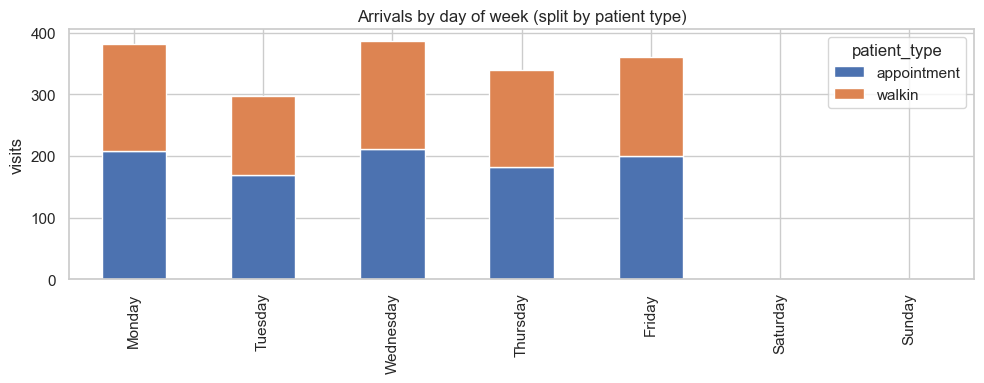

patient_type,appointment,walkin
dow,,
Monday,208.0,173.0
Tuesday,169.0,129.0
Wednesday,212.0,174.0
Thursday,182.0,158.0
Friday,200.0,160.0
Saturday,NaN,NaN
Sunday,NaN,NaN


In [7]:
arrivals = df.dropna(subset=["MUAYENE_KABUL_ZAMANI"]).copy()
arrivals["dow"] = arrivals["MUAYENE_KABUL_ZAMANI"].dt.day_name()
arrivals["hour"] = arrivals["MUAYENE_KABUL_ZAMANI"].dt.hour

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_counts = (
    arrivals.groupby(["dow", "patient_type"]).size().unstack(fill_value=0).reindex(dow_order)
)

fig, ax = plt.subplots(figsize=(10, 4))
dow_counts.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Arrivals by day of week (split by patient type)")
ax.set_ylabel("visits")
ax.set_xlabel("")
fig.tight_layout()
fig.savefig(OUT_DIR / "arrivals_by_dow.png", dpi=150)
plt.show()
dow_counts

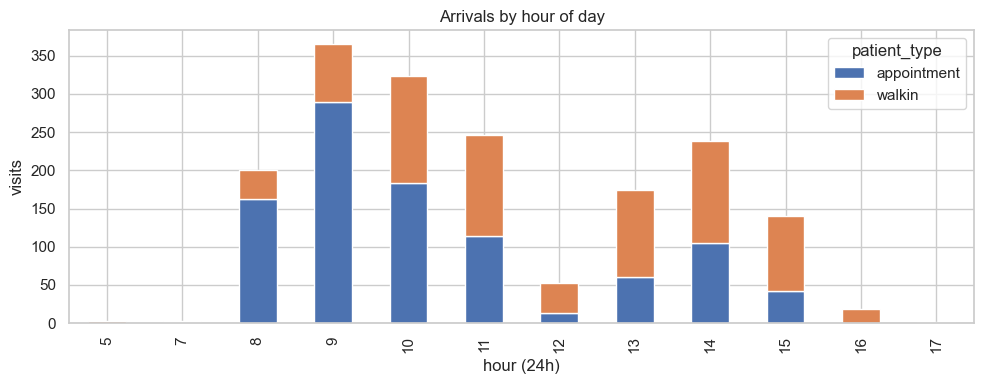

patient_type,appointment,walkin
hour,,
5,0,3
7,1,2
8,163,38
9,289,76
10,184,139
11,114,132
12,13,39
13,60,114
14,105,133


In [8]:
hour_counts = (
    arrivals.groupby(["hour", "patient_type"]).size().unstack(fill_value=0).sort_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
hour_counts.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Arrivals by hour of day")
ax.set_ylabel("visits")
ax.set_xlabel("hour (24h)")
fig.tight_layout()
fig.savefig(OUT_DIR / "arrivals_by_hour.png", dpi=150)
plt.show()
hour_counts

In [9]:
wed_check = (
    arrivals.assign(is_wed=arrivals["dow"] == "Wednesday")
    .groupby("is_wed")
    .agg(
        visits=("patient_type", "size"),
        walkin_share=("patient_type", lambda s: (s == "walkin").mean()),
        avg_total_minutes=("total_system_time", "mean"),
    )
    .rename(index={True: "Wednesday", False: "Other days"})
)
wed_check

,visits,walkin_share,avg_total_minutes
is_wed,,,
Other days,1379,0.449601,36.252342
Wednesday,386,0.450777,33.374802


In [10]:
ia_walkin = dp.inter_arrival_times(
    df[df["patient_type"] == "walkin"],
    time_column="MUAYENE_KABUL_ZAMANI",
    group_columns=("department",),
)
ia_appt = dp.inter_arrival_times(
    df[df["patient_type"] == "appointment"],
    time_column="RANDEVU_BASLAMA_SAATI",
    group_columns=("department",),
)
ia_walkin["patient_type"] = "walkin"
ia_appt["patient_type"] = "appointment"
inter_arrivals = pd.concat([ia_walkin, ia_appt], ignore_index=True)
inter_arrivals.groupby("patient_type")["inter_arrival_minutes"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
patient_type,,,,,,,,
appointment,790.0,10.55,18.00,0.50,3.00,6.0,10.00,147.0
walkin,762.0,11.62,19.85,0.02,1.88,5.1,12.11,172.2


## 4. Routing probabilities

Per-department probability that a patient is sent to the X-ray room (measured as the share of visits with a non-null `TETKIK_ISTEK_SAATI`). This populates `routing.xray_probability` in `config.yml`.

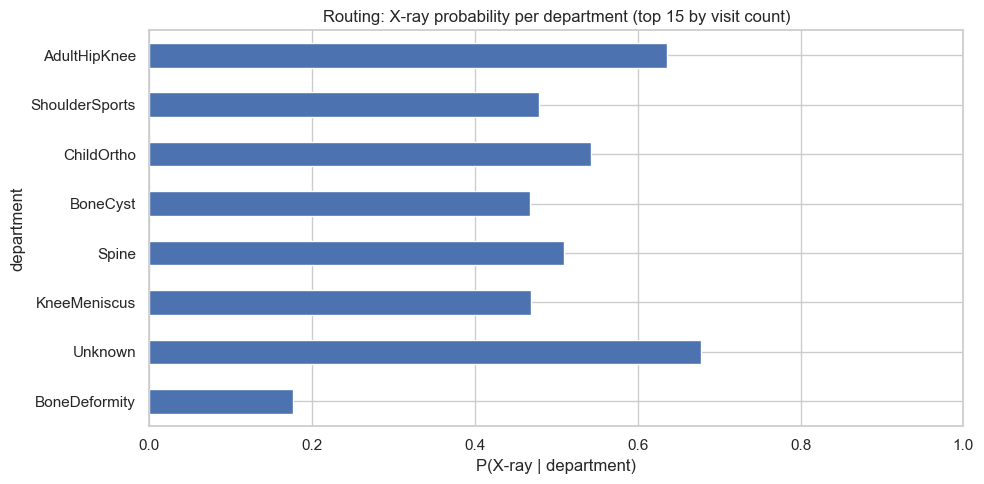

,visits,xray_visits,xray_probability
department,,,
AdultHipKnee,811,516,0.636
ShoulderSports,313,150,0.479
ChildOrtho,236,128,0.542
BoneCyst,203,95,0.468
Spine,167,85,0.509
KneeMeniscus,64,30,0.469
Unknown,59,40,0.678
BoneDeformity,17,3,0.176


In [11]:
routing = dp.compute_routing_probabilities(df)
routing.to_csv(OUT_DIR / "routing_probs.csv")

fig, ax = plt.subplots(figsize=(10, 5))
routing.head(15)["xray_probability"].plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_xlabel("P(X-ray | department)")
ax.set_title("Routing: X-ray probability per department (top 15 by visit count)")
ax.set_xlim(0, 1)
fig.tight_layout()
fig.savefig(OUT_DIR / "routing_probabilities.png", dpi=150)
plt.show()
routing.round(3)

## 5. Service time distributions

Empirical view of the three service times before we commit to a parametric fit. Each plot shows both a histogram (shape) and an empirical CDF (tail behaviour).

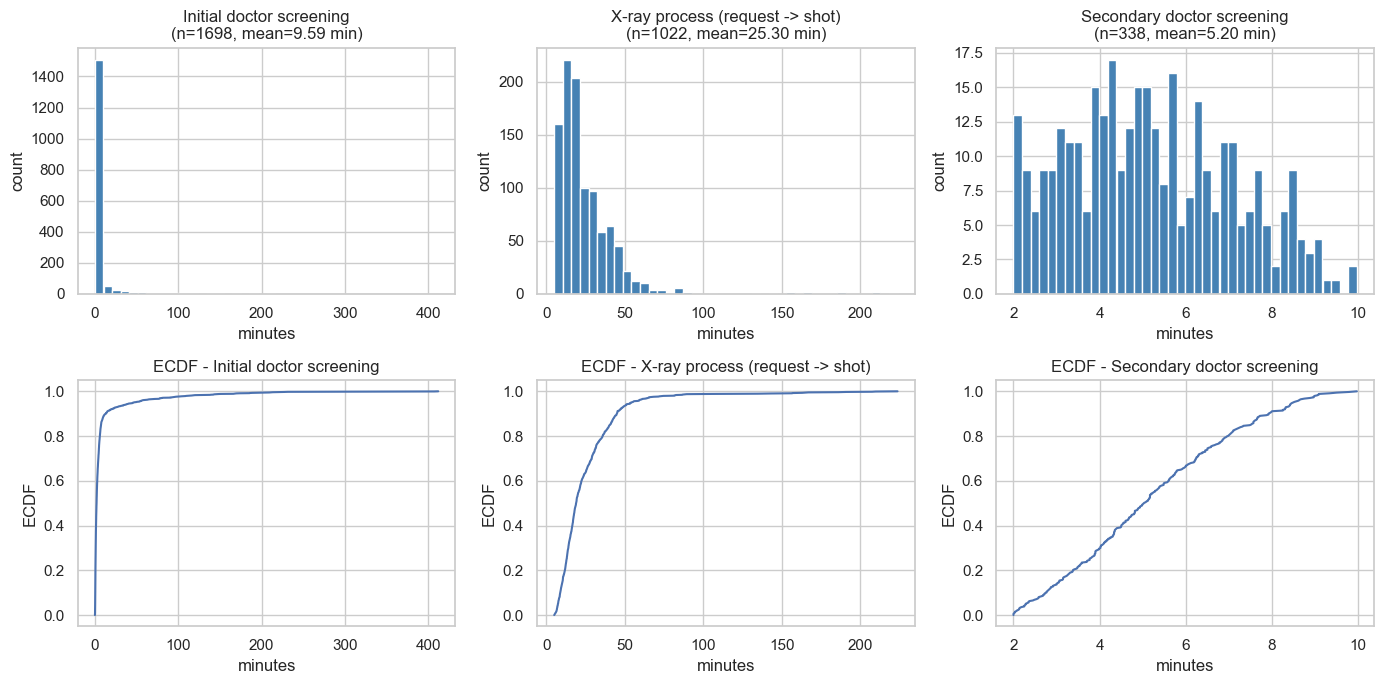

In [12]:
service_vars = {
    "initial_screening_time": "Initial doctor screening",
    "xray_wait_time": "X-ray process (request -> shot)",
    "secondary_screening_time": "Secondary doctor screening",
}

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax_hist, ax_ecdf, (col, title) in zip(axes[0], axes[1], service_vars.items()):
    samples = df[col].dropna().to_numpy()
    ax_hist.hist(samples, bins=40, color="steelblue", edgecolor="white")
    ax_hist.set_title(f"{title}\n(n={len(samples)}, mean={samples.mean():.2f} min)")
    ax_hist.set_xlabel("minutes")
    ax_hist.set_ylabel("count")
    sorted_s = np.sort(samples)
    ax_ecdf.plot(sorted_s, np.linspace(0, 1, len(sorted_s)))
    ax_ecdf.set_xlabel("minutes")
    ax_ecdf.set_ylabel("ECDF")
    ax_ecdf.set_title(f"ECDF - {title}")
fig.tight_layout()
fig.savefig(OUT_DIR / "service_time_distributions.png", dpi=150)
plt.show()

## 6. Distribution fitting (full goodness-of-fit)

For every target variable we:

- Fit six candidate distributions (`expon`, `lognorm`, `gamma`, `weibull_min`, `triang`, `norm`).
- Run a Kolmogorov-Smirnov test and a binned Chi-square test.
- Rank candidates by *accepted at alpha=0.05 first*, then highest K-S p-value, then lowest AIC.

With 300-1700 samples K-S will often reject every theoretical distribution because small shape mismatches become detectable - we therefore also inspect Q-Q plots and AIC to pick the closest-to-reality candidate for the SimPy parameters.

In [13]:
import re

def _safe_slug(label: str) -> str:
    slug = re.sub(r"[^a-z0-9]+", "_", label.lower()).strip("_")
    return slug or "var"


def fit_and_report(samples: np.ndarray, label: str):
    """Return (fit_table, winner_dict) and save a ranked GoF CSV."""
    table = dp.fit_distributions(samples)
    table.to_csv(OUT_DIR / f"gof_{_safe_slug(label)}.csv", index=False)
    winner = dp.pick_winner(table)
    display_cols = ["candidate", "params", "ks_p", "chi2_p", "aic", "is_accepted"]
    print(f"=== {label} (n={len(samples)}) ===")
    print(f"Winner: {winner['dist']} (K-S p={winner['ks_p']:.4g}, AIC={winner['aic']:.1f})")
    return table[display_cols].round(4), winner


service_fits = {}
for col, title in service_vars.items():
    samples = df[col].dropna().to_numpy()
    table, winner = fit_and_report(samples, title)
    service_fits[col] = {"table": table, "winner": winner}
    display(table)

xray_room_samples = dp.xray_samples_by_room(df)
xray_room_fits = {}
for room, samples in xray_room_samples.items():
    table, winner = fit_and_report(samples, f"xray {room} room")
    xray_room_fits[room] = {"table": table, "winner": winner}
    display(table)

=== Initial doctor screening (n=1698) ===
Winner: lognorm (K-S p=7.246e-06, AIC=8832.8)


,candidate,params,ks_p,chi2_p,aic,is_accepted
0,lognorm,"(1.4913826257503515, 0.028523968060022963, 2.1...",0.0,0.0,8832.8249,False
1,weibull_min,"(0.6253769404888478, 0.033333333333333326, 9.6...",0.0,0.0,9664.1458,False
2,expon,"(0.03333333333333333, 9.553131134668236)",0.0,0.0,11064.3270,False
3,norm,"(9.58646446800157, 30.79676677268315)",0.0,0.0,16462.1986,False
4,triang,"(1.128100198897389e-07, -0.041161796779922995,...",0.0,0.0,18213.1982,False
5,gamma,"(0.045548432636249525, 0.033333333333333326, 3...",0.0,0.0,23124.4235,False


=== X-ray process (request -> shot) (n=1022) ===
Winner: lognorm (K-S p=0.4116, AIC=8091.7)


,candidate,params,ks_p,chi2_p,aic,is_accepted
0,lognorm,"(0.8048757076523901, 3.521624845826139, 15.704...",0.4116,0.0,8091.6887,True
1,weibull_min,"(1.112612450741091, 5.06341827567625, 21.14998...",0.0155,0.0,8176.4622,False
2,expon,"(5.066666666666666, 20.237981082844097)",0.0000,0.0,8195.4549,False
3,norm,"(25.304647749510764, 22.193078519226365)",0.0000,0.0,9240.2616,False
4,triang,"(0.0024412454819820436, 4.815106572772946, 219...",0.0000,0.0,9837.8135,False
5,gamma,"(0.14442917078504552, 5.0666666666666655, 11.7...",0.0000,0.0,12538.9033,False


=== Secondary doctor screening (n=338) ===
Winner: triang (K-S p=0.7132, AIC=1360.9)


...

=== xray standing room (n=580) ===


Winner: lognorm (K-S p=0.4782, AIC=4466.6)


,candidate,params,ks_p,chi2_p,aic,is_accepted
0,lognorm,"(0.8232432459680336, 4.0364522373105105, 13.74...",0.4782,0.0197,4466.5989,True
1,weibull_min,"(1.0469961615129966, 5.348257745748763, 18.767...",0.0092,0.0000,4540.2617,False
2,expon,"(5.35, 18.372385057471263)",0.0015,0.0000,4540.5845,False
3,norm,"(23.722385057471264, 23.068310318682002)",0.0000,0.0000,5290.5821,False
4,triang,"(0.0004582922369142251, 5.269241822005537, 218...",0.0000,0.0000,5577.6202,False
5,gamma,"(0.09252565457711728, 5.349999999999999, 6.432...",0.0000,0.0000,8753.6877,False


=== xray laying room (n=435) ===
Winner: lognorm (K-S p=0.06187, AIC=3561.0)


,candidate,params,ks_p,chi2_p,aic,is_accepted
0,lognorm,"(0.7408897725990383, 2.2234800790205815, 19.43...",0.0619,0.0,3561.0257,True
1,expon,"(5.066666666666666, 22.501302681992335)",0.0004,0.0,3582.8087,False
2,norm,"(27.567969348659002, 20.90604087144672)",0.0000,0.0,3883.3097,False
3,weibull_min,"(0.8369522307370214, 5.0666666666666655, 14.23...",0.0000,0.0,3688.1587,False
4,triang,"(4.374459998105271e-05, 5.057788753315041, 202...",0.0000,0.0,4144.9327,False
5,gamma,"(0.16202329560890633, 5.0666666666666655, 6.39...",0.0000,0.0,6775.1283,False


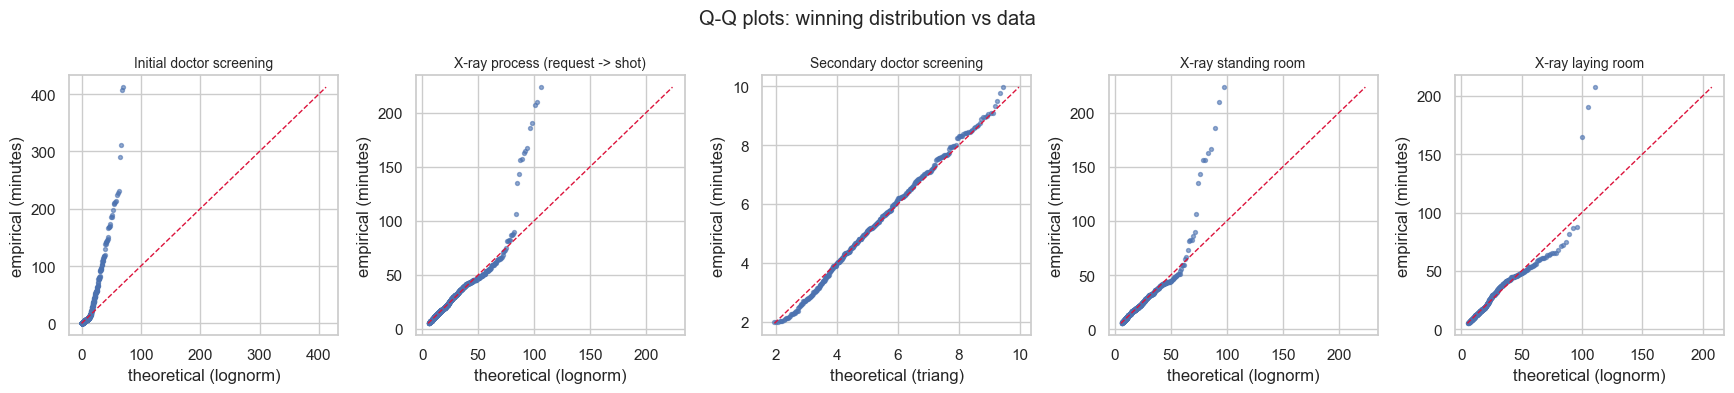

In [14]:
qq_panels: list[tuple[np.ndarray, dict, str]] = []
for col, title in service_vars.items():
    qq_panels.append((df[col].dropna().to_numpy(), service_fits[col]["winner"], title))
for room, fit in xray_room_fits.items():
    qq_panels.append((xray_room_samples[room], fit["winner"], f"X-ray {room} room"))

ncols = len(qq_panels)
fig, axes = plt.subplots(1, ncols, figsize=(3.5 * ncols, 4))
for ax, (samples, winner, title) in zip(axes, qq_panels):
    dist = getattr(stats, winner["dist"])
    theoretical = dist.ppf(np.linspace(0.01, 0.99, len(samples)), *winner["params"])
    empirical = np.sort(samples)
    ax.scatter(theoretical, empirical, s=8, alpha=0.6)
    lims = [min(theoretical.min(), empirical.min()), max(theoretical.max(), empirical.max())]
    ax.plot(lims, lims, color="crimson", linestyle="--", linewidth=1)
    ax.set_xlabel(f"theoretical ({winner['dist']})")
    ax.set_ylabel("empirical (minutes)")
    ax.set_title(title, fontsize=10)
fig.suptitle("Q-Q plots: winning distribution vs data")
fig.tight_layout()
fig.savefig(OUT_DIR / "qq_service_times.png", dpi=150)
plt.show()

### 6b. Inter-arrival distributions

Walk-ins: the data only records the time the doctor accepted the patient, not the instant they crossed the front door. We therefore jitter `MUAYENE_KABUL_ZAMANI` by a `Triangular(-10, 0, +5)` minute offset and fit the resulting inter-arrival series. This assumption is captured in `config.assumptions.walkin_jitter` and should be copied verbatim into **Section 1.4 Modelling Assumptions**.

Appointments: the scheduled slot time (`RANDEVU_BASLAMA_SAATI`) is used directly - it already reflects the clinic's booking policy.

In [15]:
walkin_df = df[df["patient_type"] == "walkin"].copy()
jitter = stats.triang(c=(0 - (-10)) / (5 - (-10)), loc=-10, scale=15).rvs(size=len(walkin_df), random_state=RNG)
walkin_df["MUAYENE_KABUL_ZAMANI_JITTERED"] = walkin_df["MUAYENE_KABUL_ZAMANI"] + pd.to_timedelta(jitter, unit="m")

ia_walkin_j = dp.inter_arrival_times(
    walkin_df,
    time_column="MUAYENE_KABUL_ZAMANI_JITTERED",
    group_columns=("department",),
)
walkin_samples = ia_walkin_j["inter_arrival_minutes"].to_numpy()
walkin_table, walkin_winner = fit_and_report(walkin_samples, "walkin inter-arrival")
display(walkin_table)

=== walkin inter-arrival (n=763) ===
Winner: lognorm (K-S p=0.5287, AIC=5089.7)


,candidate,params,ks_p,chi2_p,aic,is_accepted
0,lognorm,"(1.3664762129900294, -0.12967309408066102, 4.9...",0.5287,0.462,5089.6708,True
1,weibull_min,"(0.6979440241738416, 0.0006199688333333333, 10...",0.0000,0.000,5107.6003,False
2,expon,"(0.0006199688333333334, 11.62200666815557)",0.0000,0.000,5273.1261,False
3,norm,"(11.622626636988905, 19.66800853458086)",0.0000,0.000,6715.2441,False
4,triang,"(8.616256719248653e-05, -0.014684814672853201,...",0.0000,0.000,6982.7630,False
5,gamma,"(0.11529103876110247, 0.0006199688333333333, 3...",0.0000,0.000,10769.3667,False


In [16]:
appt_samples = ia_appt["inter_arrival_minutes"].to_numpy()
appt_table, appt_winner = fit_and_report(appt_samples, "appointment inter-arrival")
display(appt_table)

appt_mode = (
    pd.Series(ia_appt["inter_arrival_minutes"].round(0).astype(int))
    .value_counts()
    .head(5)
)
print("Top 5 scheduled inter-arrival values (appointments):")
print(appt_mode)

=== appointment inter-arrival (n=790) ===
Winner: lognorm (K-S p=5.308e-07, AIC=5035.8)


,candidate,params,ks_p,chi2_p,aic,is_accepted
0,lognorm,"(1.0564329583026255, 0.2367421959099008, 5.526...",0.0,0.0,5035.7896,False
1,weibull_min,"(0.712970732016726, 0.9999999999999999, 5.7366...",0.0,0.0,inf,False
2,expon,"(0.5, 10.045569620253165)",0.0,0.0,5229.2681,False
3,norm,"(10.545569620253165, 17.99074514164108)",0.0,0.0,6811.8977,False
4,triang,"(1.3833237915629082e-08, 0.4999959794705161, 1...",0.0,0.0,6946.3230,False
5,gamma,"(0.0861458906492257, 0.49999999999999994, 3.15...",0.0,0.0,10886.5593,False


Top 5 scheduled inter-arrival values (appointments):
inter_arrival_minutes
2    122
7     87
8     78
4     76
6     63
Name: count, dtype: int64


## 7. Emit `config.yml`

All the fitted parameters get written to `config.yml` so `simulation.py` (built in the next milestone) can consume them without touching the data. The file is human-readable and can be tweaked manually for what-if scenarios in the Streamlit dashboard.

In [17]:
def winner_block(winner: dict) -> dict:
    return {
        "dist": winner["dist"],
        "params": [float(x) for x in winner["params"]],
        "ks_p": float(winner["ks_p"]),
        "aic": float(winner["aic"]),
        "n": int(winner["n"]),
    }


departments = routing.index.tolist()

config = {
    "resources": {
        "doctors_per_department": {dept: 1 for dept in departments},
        "xray_rooms": {"standing": 1, "laying": 1},
    },
    "routing": {
        "xray_probability": {
            dept: float(round(p, 4))
            for dept, p in routing["xray_probability"].items()
        }
    },
    "service_times": {
        "initial_screening": winner_block(service_fits["initial_screening_time"]["winner"]),
        "xray_process": {
            "pooled": winner_block(service_fits["xray_wait_time"]["winner"]),
            "standing": winner_block(xray_room_fits["standing"]["winner"]),
            "laying": winner_block(xray_room_fits["laying"]["winner"]),
        },
        "secondary_screening": winner_block(service_fits["secondary_screening_time"]["winner"]),
    },
    "arrivals": {
        "walkin": winner_block(walkin_winner),
        "appointment": winner_block(appt_winner),
    },
    "assumptions": {
        "walkin_jitter": {
            "dist": "triang",
            "min_minutes": -10,
            "mode_minutes": 0,
            "max_minutes": 5,
            "note": "Patient crossed the front door somewhere in this window relative to MUAYENE_KABUL_ZAMANI.",
        },
        "follow_up_day": "Wednesday",
        "late_arrival_cutoff": "16:00",
        "scoliosis_room_id": 160,
        "appointment_deviation_hours": 1.0,
    },
}

with open("config.yml", "w", encoding="utf-8") as fh:
    yaml.safe_dump(config, fh, sort_keys=False, allow_unicode=True)
print("Wrote config.yml")
print(yaml.safe_dump(config["service_times"], sort_keys=False, allow_unicode=True))

Wrote config.yml
initial_screening:
  dist: lognorm
  params:
  - 1.4913826257503515
  - 0.028523968060022963
  - 2.1826520330288774
  ks_p: 7.246431427151981e-06
  aic: 8832.82487703388
  n: 1698
xray_process:
  pooled:
    dist: lognorm
    params:
    - 0.8048757076523901
    - 3.521624845826139
    - 15.704468308088941
    ks_p: 0.4116268432861576
    aic: 8091.688714979158
    n: 1022
  standing:
    dist: lognorm
    params:
    - 0.8232432459680336
    - 4.0364522373105105
    - 13.748213824836718
    ks_p: 0.4781557933520588
    aic: 4466.598904701567
    n: 580
  laying:
    dist: lognorm
    params:
    - 0.7408897725990383
    - 2.2234800790205815
    - 19.4374433743562
    ks_p: 0.0618718419399803
    aic: 3561.0256595133633
    n: 435
secondary_screening:
  dist: triang
  params:
  - 0.2775979155359286
  - 1.4811324227464793
  - 8.713565622924111
  ks_p: 0.7131876633060098
  aic: 1360.9214771938255
  n: 338



## 8. QA sanity check

Re-read `config.yml`, draw 10 000 samples from each fitted distribution, and compare the simulated mean/std/quantiles against the empirical values. If any row's ratio is wildly off (> 20% deviation in mean or std) we flag it for manual review before using the config in `simulation.py`.

In [18]:
with open("config.yml", "r", encoding="utf-8") as fh:
    reloaded = yaml.safe_load(fh)

qa_specs = [
    ("service_times.initial_screening", reloaded["service_times"]["initial_screening"], df["initial_screening_time"].dropna().to_numpy()),
    ("service_times.xray_process.pooled", reloaded["service_times"]["xray_process"]["pooled"], df["xray_wait_time"].dropna().to_numpy()),
    ("service_times.xray_process.standing", reloaded["service_times"]["xray_process"]["standing"], xray_room_samples["standing"]),
    ("service_times.xray_process.laying", reloaded["service_times"]["xray_process"]["laying"], xray_room_samples["laying"]),
    ("service_times.secondary_screening", reloaded["service_times"]["secondary_screening"], df["secondary_screening_time"].dropna().to_numpy()),
    ("arrivals.walkin", reloaded["arrivals"]["walkin"], walkin_samples),
    ("arrivals.appointment", reloaded["arrivals"]["appointment"], appt_samples),
]

rows = []
for name, spec, empirical in qa_specs:
    dist = getattr(stats, spec["dist"])
    sim = dist.rvs(*spec["params"], size=10_000, random_state=RNG)
    rows.append(
        {
            "variable": name,
            "dist": spec["dist"],
            "n_empirical": len(empirical),
            "mean_emp": float(np.mean(empirical)),
            "mean_sim": float(np.mean(sim)),
            "std_emp": float(np.std(empirical)),
            "std_sim": float(np.std(sim)),
            "p50_emp": float(np.median(empirical)),
            "p50_sim": float(np.median(sim)),
            "mean_pct_diff": float(abs(np.mean(sim) - np.mean(empirical)) / max(np.mean(empirical), 1e-9) * 100),
        }
    )

qa = pd.DataFrame(rows)
qa["flag"] = qa["mean_pct_diff"].apply(lambda x: "OK" if x < 20 else "REVIEW")
qa.to_csv(OUT_DIR / "qa_sanity_check.csv", index=False)
qa.round(3)

,variable,dist,n_empirical,mean_emp,mean_sim,std_emp,std_sim,p50_emp,p50_sim,mean_pct_diff,flag
0,service_times.initial_screening,lognorm,1698,9.586,6.580,30.797,15.773,2.033,2.282,31.359,REVIEW
1,service_times.xray_process.pooled,lognorm,1022,25.305,25.410,22.193,20.473,19.008,19.409,0.417,OK
2,service_times.xray_process.standing,lognorm,580,23.722,23.471,23.068,19.268,17.933,17.833,1.062,OK
3,service_times.xray_process.laying,lognorm,435,27.568,27.821,20.906,21.506,21.900,21.726,0.919,OK
4,service_times.secondary_screening,triang,338,5.195,5.200,1.898,1.842,5.025,4.955,0.084,OK
5,arrivals.walkin,lognorm,763,11.623,12.310,19.668,27.341,5.070,4.767,5.913,OK
6,arrivals.appointment,lognorm,790,10.546,9.781,17.991,13.302,6.000,5.780,7.254,OK


## Outputs summary

The `outputs/` folder now contains everything that needs to go into the report:

- `cleaning_audit.csv` - Section 1.3 data-quality table
- `missing_value_heatmap.png`, `arrivals_by_dow.png`, `arrivals_by_hour.png` - Section 1.3 figures
- `service_time_distributions.png`, `qq_service_times.png` - Section 1.3 / 1.4 figures
- `routing_probs.csv`, `routing_probabilities.png` - Section 1.4 / 2.1 routing probabilities
- `gof_*.csv` - one goodness-of-fit table per fitted variable
- `qa_sanity_check.csv` - proof that `config.yml` reproduces the empirical moments

Resolved open items:

1. `DOKTOR_ADI -> department` mapping comes from `Baltalimani_Data_2025.csv` (first-specialty rule). Produces 8 departments plus `Unknown` for the one unlisted doctor.
2. Late-arrival cutoff fixed at 16:00 per the clinic's end-of-day policy.
3. `config.service_times.xray_process` now exposes **three** distributions: `pooled`, `standing`, and `laying`. The simulation can choose the split based on the target patient's modality.